# Verify work from scripts is correct

## (1) data from youtube_collector.py

In [1]:
import pandas as pd 

# read in the csv generated from 10 test rows 
test_10 = pd.read_csv("../data/raw/metadata.csv")

# verify cols and count 
test_10.columns

# check that image data is usable
# image is jpg format 
test_10['thumbnail_url'].iloc[0]

count_rows = len(test_10)
print(count_rows)

# head check 
test_10.head(10)

50


,video_id,channel,publish_date,title,thumbnail_url,views,likes,comments
0,4yauPjEce8I,Loveneet Valecha,2025-12-30T10:52:33Z,Finally humare ghar bhi ban gaya😅 #cooking #fo...,https://i.ytimg.com/vi/4yauPjEce8I/hqdefault.jpg,304673799,2812599.0,4607.0
1,yh4nSLUR0So,Lưu Quang Minh Review,2026-03-30T04:08:51Z,Xúc Xích Nướng Giấy Bạc ngon tuyệt! #xucxich #...,https://i.ytimg.com/vi/yh4nSLUR0So/hqdefault.jpg,235,2.0,0.0
2,3VpWb7bK9cg,Daily Lici,2026-03-30T03:40:58Z,#pinbutton #alatpresspin #mesinpin #diy #tutorial,https://i.ytimg.com/vi/3VpWb7bK9cg/hqdefault.jpg,773,7.0,0.0
3,j8ZxI2no9gw,chop-ru,2025-06-30T09:10:00Z,Satisfying With Unboxing & Review Pink Mini Ki...,https://i.ytimg.com/vi/j8ZxI2no9gw/hqdefault.jpg,96131545,293541.0,60.0
4,DO5MflX_eik,Odysseas,2025-12-20T16:23:54Z,I’m begging you to write essays,https://i.ytimg.com/vi/DO5MflX_eik/hqdefault.jpg,1247285,84560.0,2181.0
5,0AxZM6TmoiM,Ángel soy yo,2025-09-14T00:05:49Z,Tutorial como comerte una espiropapa🥔corregido,https://i.ytimg.com/vi/0AxZM6TmoiM/hqdefault.jpg,152567895,2577476.0,7101.0
6,rB4ONN2Bolk,মেন্টাল সামিম,2026-03-30T04:03:45Z,সারাদিন বাড়ির বাহিরে 🏠 😜| #minivlog #vlog,https://i.ytimg.com/vi/rB4ONN2Bolk/hqdefault.jpg,491,4.0,0.0
7,6p4phB2Rybs,daily mind trap,2025-04-13T16:00:07Z,What’s Wrong With Eating Humans?,https://i.ytimg.com/vi/6p4phB2Rybs/hqdefault.jpg,1673469,92970.0,6794.0
8,thzpvP4Hseg,Poofy💨,2025-08-15T15:44:07Z,If you want a textured fringe do this,https://i.ytimg.com/vi/thzpvP4Hseg/hqdefault.jpg,184852752,2115356.0,14661.0
9,vBGd4COy8BY,FutbolEssence,2025-07-25T02:57:21Z,#effectking,https://i.ytimg.com/vi/vBGd4COy8BY/hqdefault.jpg,21528121,188842.0,1593.0


## (2) data from extract_features.py

In [ ]:
features_df = pd.read_csv("../data/processed/features.csv")

features_df.columns

len(features_df)

features_df.head(15)

# it seems a lot of the cols are not capturing meaningful data
features_df.select_dtypes(include='number').std()
features_df.describe()

"""
WEAKER FEATURES:
edge_density
entropy
symmetry 
"""

,edge_density,blur,corner_count,contrast,views,keypoint_count,colorfulness,brightness,entropy,text_length,text_count,text_presence,face_count,symmetry
count,50.000000,50.000000,50.000000,50.000000,5.000000e+01,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,0.065977,1382.126544,284.220000,63.474467,8.253357e+07,2924.720000,105.332197,78.296585,4.662943,5.200000,1.080000,0.160000,0.580000,0.876203
std,0.030382,1575.829225,132.508958,11.220160,1.936807e+08,1165.629322,24.585194,20.616394,0.492986,17.046156,3.652452,0.370328,0.835195,0.055894
min,0.009485,215.561296,27.000000,43.142453,3.000000e+00,432.000000,32.908893,23.147552,2.773941,0.000000,0.000000,0.000000,0.000000,0.701819
25%,0.044275,671.116191,181.250000,56.371590,5.220000e+02,2064.000000,93.359643,66.170165,4.623876,0.000000,0.000000,0.000000,0.000000,0.849212
50%,0.063550,951.826509,302.500000,62.048079,4.982080e+05,3291.500000,109.547574,79.539314,4.770137,0.000000,0.000000,0.000000,0.000000,0.883814
75%,0.087794,1518.707896,373.000000,70.327348,8.362782e+07,3931.500000,122.589672,87.839501,4.991439,0.000000,0.000000,0.000000,1.000000,0.906841
max,0.154705,10362.059586,624.000000,92.109275,1.116442e+09,4677.000000,138.572733,126.632222,5.251759,109.000000,24.000000,1.000000,3.000000,0.967166


## (3) data from test_robustness.py 

In [29]:
robustness_df = pd.read_csv("../data/processed/robustness_results.csv")

robustness_df.head(-10)
# len(robustness_df)

# wide_robustness_df = robustness_df.groupby("video_id")["difference"].mean()
# wide_robustness_df.head(10)

,video_id,feature,transformation,difference
0,4yauPjEce8I,edge_density,resize_640x360,0.014135
1,4yauPjEce8I,blur,resize_640x360,698.981610
2,4yauPjEce8I,corner_count,resize_640x360,109.000000
3,4yauPjEce8I,contrast,resize_640x360,0.390705
4,4yauPjEce8I,keypoint_count,resize_640x360,271.000000
...,...,...,...,...
9735,2mY_YUUdRBk,face_count,noise_s15,0.000000
9736,2mY_YUUdRBk,symmetry,noise_s15,0.217440
9737,2mY_YUUdRBk,edge_density,noise_s30,0.248056
9738,2mY_YUUdRBk,blur,noise_s30,83666.657085


## Can we conclude correlation?

In [ ]:
# calculate different types of correlations 
corr = features_df.corr(numeric_only=True)["views"].sort_values(ascending=False)
print(corr)

""" 
higher contrast -> lower views 
higher symmetry slightly higher views 
mostly negative relationships 
"""

# merge on video_id to get engagement metadata with transformations 
robust_mean = robustness_df.groupby("feature")["difference"].mean()

# merge_df = features_df.copy()
# pandas align by feature name to compare correlation and robustness
analysis = pd.DataFrame({
    "correlation": corr,
    "robustness": robust_mean
}).dropna()

print(analysis.sort_values("correlation", ascending=False))
""" 
overall no strong correlations to views 
best features:
- symmetry 
- entropy is weak corr but stable 

stable but not useful 
- text, all 0 

negative correlations and stable 
- higher contrast 
- colorfulness 
- brightness

"""

views             1.000000
symmetry          0.178845
entropy           0.050135
face_count       -0.013685
brightness       -0.022176
colorfulness     -0.098779
corner_count     -0.119324
text_count       -0.128283
text_length      -0.132311
blur             -0.148803
edge_density     -0.174104
keypoint_count   -0.177774
text_presence    -0.187245
contrast         -0.296921
Name: views, dtype: float64
                correlation    robustness
symmetry           0.178845      0.032197
entropy            0.050135      0.118604
face_count        -0.013685      0.286667
brightness        -0.022176     17.393007
colorfulness      -0.098779      4.847817
corner_count      -0.119324    164.393333
text_count        -0.128283      0.000000
text_length       -0.132311      0.000000
blur              -0.148803  14429.215420
edge_density      -0.174104      0.071103
keypoint_count    -0.177774   1155.338667
text_presence     -0.187245      0.000000
contrast          -0.296921      2.791614


# Project shift 

### test extract_keypoints.py and draw_keypoints.py

Keypoints: 588


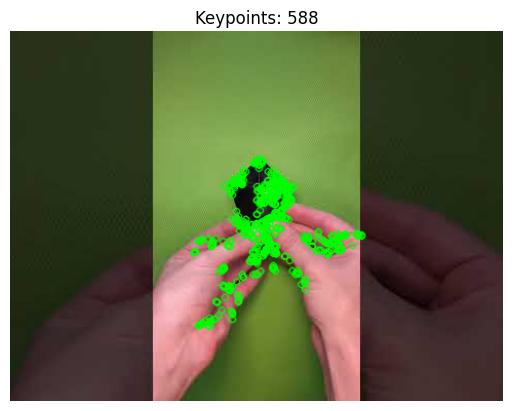

In [4]:
import cv2
import sys
import os

sys.path.append(os.path.abspath(".."))
from src.keypoint_analysis.extract_keypoints import extract_keypoints, draw_keypoints

img = cv2.imread("../data/raw/images/_fXpf-qBca4.jpg")

kp, count = extract_keypoints(img)
img_kp = draw_keypoints(img, kp)

print("Keypoints:", count)

cv2.imshow("Keypoints", img_kp)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

import matplotlib.pyplot as plt

# Convert BGR → RGB (important)
img_rgb = cv2.cvtColor(img_kp, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title(f"Keypoints: {count}")
plt.axis("off")
plt.show()

### transformations 

In [6]:
from src.keypoint_analysis.transformations import (
    resize_variants,
    compress_variants,
    blur_variants,
    noise_variants
)

import cv2

img = cv2.imread("../data/raw/images/_fXpf-qBca4.jpg")

if img is None:
    raise ValueError("Image failed to load")


resize_out = resize_variants(img)
resize_out.keys()

compress_out = compress_variants(img)
compress_out.keys()

blur_out = blur_variants(img)
blur_out.keys()

noise_out = noise_variants(img)
noise_out.keys()
transforms = {
    **resize_out,
    **compress_out,
    **blur_out,
    **noise_out
}

len(transforms)

15

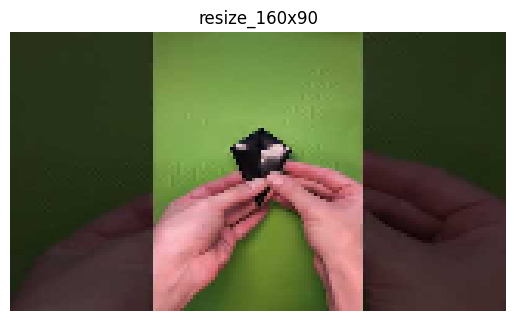

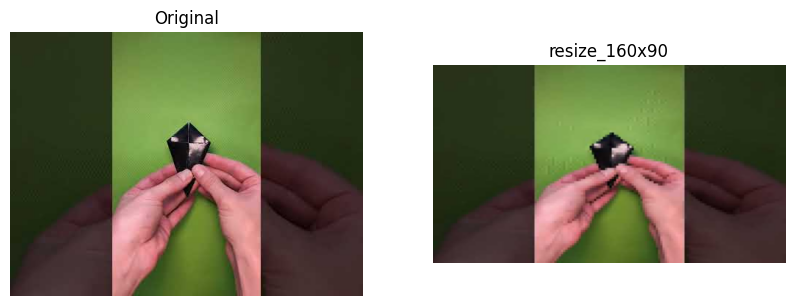

In [8]:
import matplotlib.pyplot as plt

name = "resize_160x90"
t_img = transforms[name]

plt.imshow(cv2.cvtColor(t_img, cv2.COLOR_BGR2RGB))
plt.title(name)
plt.axis("off")
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(10,5))

ax[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(cv2.cvtColor(t_img, cv2.COLOR_BGR2RGB))
ax[1].set_title(name)
ax[1].axis("off")

plt.show()